In [34]:
import os
from dotenv import load_dotenv
load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY")

In [ ]:
# from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
# from pprint import pprint

# messages = [
#     AIMessage(content="Hello, Please tell me how can I help?")
# ]
# messages.append(HumanMessage(content="I want to learn coding"))
# messages.append(AIMessage(content = "Sure, I can help you with that. What programming language are you interested in?"))
# messages.append(HumanMessage(content="I want to learn python programmig"))

# for i in messages:
#     i.pretty_print()

================================== Ai Message ==================================

Hello, Please tell me how can I help?
================================ Human Message =================================

I want to learn coding
================================== Ai Message ==================================

Sure, I can help you with that. What programming language are you interested in?
================================ Human Message =================================

I want to learn python programmig


In [ ]:
from langchain_groq import ChatGroq
llm = ChatGroq(model_name = "llama-3.1-8b-instant",groq_api_key = groq_api_key)
# result = llm.invoke(messages)
# print(result.content)

Python is a popular and versatile language that's easy to learn and fun to use. Here's a step-by-step guide to help you get started:

**Why Learn Python?**

1. **Easy to learn**: Python has a simple syntax and is relatively easy to read and write.
2. **Versatile**: Python can be used for web development, data analysis, machine learning, automation, and more.
3. **Large community**: Python has a massive and active community, which means there are many resources available to help you learn.

**Basic Steps to Learn Python:**

1. **Get a Python IDE (Integrated Development Environment)**: Some popular options include PyCharm, Visual Studio Code, and Spyder.
2. **Learn the basics**: Start with basic syntax, data types, variables, control structures, functions, and modules.
3. **Practice**: Practice writing code to solve problems and exercises.
4. **Learn Python libraries and frameworks**: Explore popular libraries like NumPy, pandas, and Flask.
5. **Build projects**: Apply your skills to rea

In [37]:
def add(a:int,b:int):
    """Add two numbers and return the result
     Args:
      a (int): the first number
      b (int): the second number
      returns: int: the sum of a and b"""

    return a + b

In [ ]:
# Binding tool with llm
llm_with_tools = llm.bind_tools([add])
# llm_with_tools.invoke([HumanMessage(content="What is the sum of 2 plus 2?")])

In [71]:
from typing_extensions import TypedDict
from typing import Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
class Typedictstate(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

In [ ]:
# initial_messages = [AIMessage(content = "Hello, Please tell me how can I help?")]
# initial_messages.append(HumanMessage(content="I want to learn coding"))

# ai_message = AIMessage(content="Sure, I can help you with that. What programming language are you interested in?")

# # use the reducers
# add_messages(initial_messages,ai_message)


[AIMessage(content='Hello, Please tell me how can I help?', additional_kwargs={}, response_metadata={}, id='ebf8a9e1-29ad-40f8-9796-1337c7ac1916', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, id='41a81223-eb38-40bb-8e7a-f6fa51eeb4a1'),
 AIMessage(content='Sure, I can help you with that. What programming language are you interested in?', additional_kwargs={}, response_metadata={}, id='73c9eb55-9aea-421b-8a94-e32013b586b1', tool_calls=[], invalid_tool_calls=[])]

In [72]:
# create the stategraph

def llm_model(state:Typedictstate):
    return {"messages":llm.invoke(state["messages"])}



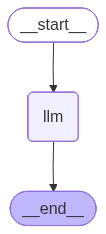

In [42]:
from langgraph.graph import StateGraph,START, END
from IPython.display import display,Image
graph = StateGraph(Typedictstate)

# adding the nodes
graph.add_node("llm", llm)
# add the edges
graph.add_edge(START,"llm")
graph.add_edge("llm",END)

# compile the graph
graph_builder = graph.compile()
# visualize the graph
visualize_graph = graph_builder.get_graph().draw_mermaid_png()
display(Image(visualize_graph))

In [53]:
messages = graph_builder.invoke({"message":"what is 2 plus 2?"})
for i in messages["message"]:
    i.pretty_print()

ValueError: Invalid input type <class 'dict'>. Must be a PromptValue, str, or list of BaseMessages.

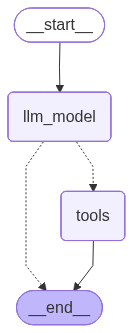

In [73]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

graph2 = StateGraph(Typedictstate)
tools = [add]
# adding the nodes
graph2.add_node("llm_model",llm_model)
graph2.add_node("tools",ToolNode(tools))
# adding the edges
graph2.add_edge(START,"llm_model")
graph2.add_conditional_edges("llm_model", tools_condition)
graph2.add_edge("tools",END)

graph2_builder = graph2.compile()

visualize_graph = graph2_builder.get_graph().draw_mermaid_png()
display(Image(visualize_graph))

In [77]:
message = graph2_builder.invoke({"messages":"What is the plus of 2 + 2?"})

for i in message["messages"]:
    i.pretty_print()

================================ Human Message =================================

What is the plus of 2 + 2?
================================== Ai Message ==================================

The result of 2 + 2 is 4.


In [80]:
message = graph2_builder.invoke({"messages":"What is the sum of 34 and 7890657373737373?"})
for i in message["messages"]:
    i.pretty_print()

================================ Human Message =================================

What is the sum of 34 and 7890657373737373?
================================== Ai Message ==================================

The sum of 34 and 7890657373737373 is a very large number. To simplify the calculation, I will perform the operation step by step.

34 + 7890657373737373 = ?

To calculate this, I'll start from the right side of the number.

1. 4 (from 34) + 3 (from 7890657373737373) = 7
2. 4 (from 34) + 7 (from the next digit) = 11, so 11 carries over to the next step (1)
3. 3 (from 34) + 3 (from the next digit) + 1 (carryover) = 7
4. 3 (from 34) + 6 (from the next digit) + 1 (carryover) = 10, so 10 carries over to the next step (1)
5.  and so on for the next 24 digits
However, this is more complicated than it needs to be.

Let's simplify the operation by first adding 10000 to 34, to make the addition easier. 

34 + 10000 = 10334

Now, we can add 7890657373737373 to 10334. This will make the calcu